In [1]:
print("Day 4 Started")

Day 4 Started


In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

sns.set_theme(style="whitegrid")

In [8]:
nav = pd.read_csv("../data/processed/clean_nav_history.csv")

performance = pd.read_csv(
    "../data/processed/clean_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../data/raw/10_benchmark_indices.csv"
)

print(nav.shape)
print(performance.shape)
print(benchmark.shape)

(46000, 3)
(40, 19)
(8050, 3)


In [10]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code","date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")
    ["nav"]
    .pct_change()
)

In [11]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


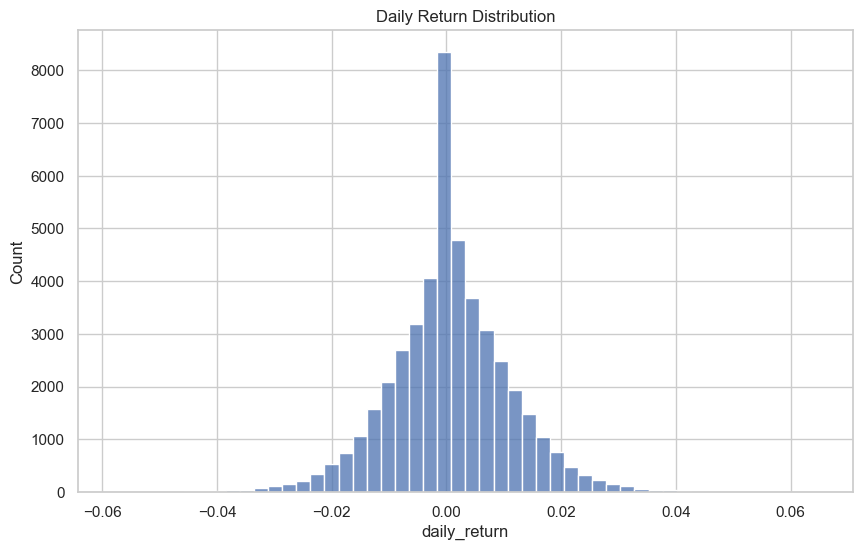

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title(
    "Daily Return Distribution"
)

plt.show()

In [13]:
cagr_results = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ]

    start_nav = temp.iloc[0]["nav"]
    end_nav = temp.iloc[-1]["nav"]

    years = (
        temp["date"].max()
        -
        temp["date"].min()
    ).days / 365

    cagr = (
        (end_nav / start_nav)
        ** (1/years)
        - 1
    )

    cagr_results.append(
        [code,cagr]
    )

cagr_df = pd.DataFrame(
    cagr_results,
    columns=[
        "amfi_code",
        "cagr"
    ]
)

cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [20]:
rf = 0.065

sharpe_results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    annual_return = returns.mean() * 252

    annual_volatility = (
        returns.std()
        * np.sqrt(252)
    )

    sharpe = (
        annual_return - rf
    ) / annual_volatility

    sharpe_results.append(
        [code, sharpe]
    )

sharpe_df = pd.DataFrame(
    sharpe_results,
    columns=[
        "amfi_code",
        "sharpe_ratio"
    ]
)

sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661


In [21]:
sortino_results = []

for code in nav["amfi_code"].unique():

    returns = nav[
        nav["amfi_code"] == code
    ]["daily_return"].dropna()

    downside = returns[
        returns < 0
    ]

    annual_return = (
        returns.mean()
        * 252
    )

    downside_volatility = (
        downside.std()
        * np.sqrt(252)
    )

    sortino = (
        annual_return - rf
    ) / downside_volatility

    sortino_results.append(
        [code, sortino]
    )

sortino_df = pd.DataFrame(
    sortino_results,
    columns=[
        "amfi_code",
        "sortino_ratio"
    ]
)

sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [16]:
benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark = benchmark.sort_values(
    ["index_name","date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")
    ["close_value"]
    .pct_change()
)

In [17]:
cagr_df.head()

,amfi_code,cagr
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [18]:
sharpe_df.head()

,amfi_code,sharpe_ratio
0,100016,-50.782301
1,100025,-142.907888
2,100033,275.612083
3,101206,258.857759
4,101207,40.990514


In [19]:
sortino_df.head()

,amfi_code,sortino_ratio
0,100016,-88.463960
1,100025,-237.338952
2,100033,460.941758
3,101206,453.489844
4,101207,69.714237


In [22]:
sharpe_df.describe()

,amfi_code,sharpe_ratio
count,40.000000,40.000000
mean,120247.000000,0.537220
std,14534.998667,0.573689
min,100016.000000,-0.815567
25%,118632.750000,0.064696
50%,119551.500000,0.647043
75%,120842.250000,1.005304
max,149324.000000,1.448291


In [23]:
sortino_df.describe()

,amfi_code,sortino_ratio
count,40.000000,40.000000
mean,120247.000000,0.923338
std,14534.998667,1.005410
min,100016.000000,-1.681038
25%,118632.750000,0.106664
50%,119551.500000,1.116936
75%,120842.250000,1.727739
max,149324.000000,2.385644


In [24]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100 = nifty100[
    ["date", "benchmark_return"]
]

nifty100.head()

,date,benchmark_return
1150,2022-01-03,NaN
1151,2022-01-04,-0.013540
1152,2022-01-05,0.004003
1153,2022-01-06,-0.002935
1154,2022-01-07,0.006150


In [25]:
alpha_beta = []

for code in nav["amfi_code"].unique():

    fund = nav[
        nav["amfi_code"] == code
    ][["date", "daily_return"]]

    merged = pd.merge(
        fund,
        nifty100,
        on="date",
        how="inner"
    ).dropna()

    if len(merged) > 50:

        slope, intercept, r, p, se = linregress(
            merged["benchmark_return"],
            merged["daily_return"]
        )

        beta = slope
        alpha = intercept * 252

        alpha_beta.append(
            [code, alpha, beta]
        )

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=[
        "amfi_code",
        "alpha",
        "beta"
    ]
)

alpha_beta_df.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [26]:
alpha_beta_df.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


In [27]:
drawdowns = []

for code in nav["amfi_code"].unique():

    temp = nav[
        nav["amfi_code"] == code
    ].copy()

    temp["running_max"] = (
        temp["nav"].cummax()
    )

    temp["drawdown"] = (
        temp["nav"]
        /
        temp["running_max"]
        - 1
    )

    max_dd = temp["drawdown"].min()

    drawdowns.append(
        [code, max_dd]
    )

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=[
        "amfi_code",
        "max_drawdown"
    ]
)

drawdown_df.head()

,amfi_code,max_drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [28]:
scorecard = (
    cagr_df
    .merge(sharpe_df)
    .merge(alpha_beta_df)
    .merge(drawdown_df)
)

scorecard = scorecard.merge(
    performance[
        ["amfi_code", "expense_ratio_pct"]
    ]
)

In [29]:
scorecard["return_rank"] = (
    scorecard["cagr"]
    .rank(ascending=False)
)

scorecard["sharpe_rank"] = (
    scorecard["sharpe_ratio"]
    .rank(ascending=False)
)

scorecard["alpha_rank"] = (
    scorecard["alpha"]
    .rank(ascending=False)
)

scorecard["expense_rank"] = (
    scorecard["expense_ratio_pct"]
    .rank()
)

scorecard["dd_rank"] = (
    scorecard["max_drawdown"]
    .rank(ascending=False)
)

In [30]:
scorecard["fund_score"] = (

    0.30 * scorecard["return_rank"]

    +

    0.25 * scorecard["sharpe_rank"]

    +

    0.20 * scorecard["alpha_rank"]

    +

    0.15 * scorecard["expense_rank"]

    +

    0.10 * scorecard["dd_rank"]

)

scorecard = scorecard.sort_values(
    "fund_score"
)

scorecard.head(10)

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,0.328016,1.180101,0.292636,0.000549,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,6.900
34,148567,0.309499,1.448291,0.269838,0.023684,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,7.400
30,120843,0.308833,1.306744,0.273305,-0.022830,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,7.900
2,100033,0.300997,1.093699,0.271954,0.005104,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,9.600
36,148569,0.319245,1.234930,0.282704,0.018134,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,10.325
21,119598,0.323981,0.945308,0.303370,-0.023196,-0.287060,1.43,2.0,14.0,1.0,21.0,36.0,11.050
24,120504,0.232774,1.026524,0.211948,0.016232,-0.125883,0.80,13.0,10.0,13.0,12.0,12.0,12.000
20,119552,0.215080,0.953279,0.198686,-0.026159,-0.118035,0.66,15.0,12.0,15.0,4.0,11.0,12.200
39,149324,0.322621,0.949796,0.300579,0.011455,-0.311719,1.52,3.0,13.0,2.0,26.5,37.0,12.225
19,119551,0.257849,1.208267,0.232010,-0.031751,-0.150124,1.54,10.0,4.0,10.0,30.5,17.0,12.275


In [31]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


In [32]:
top5 = (
    scorecard["amfi_code"]
    .head(5)
    .tolist()
)

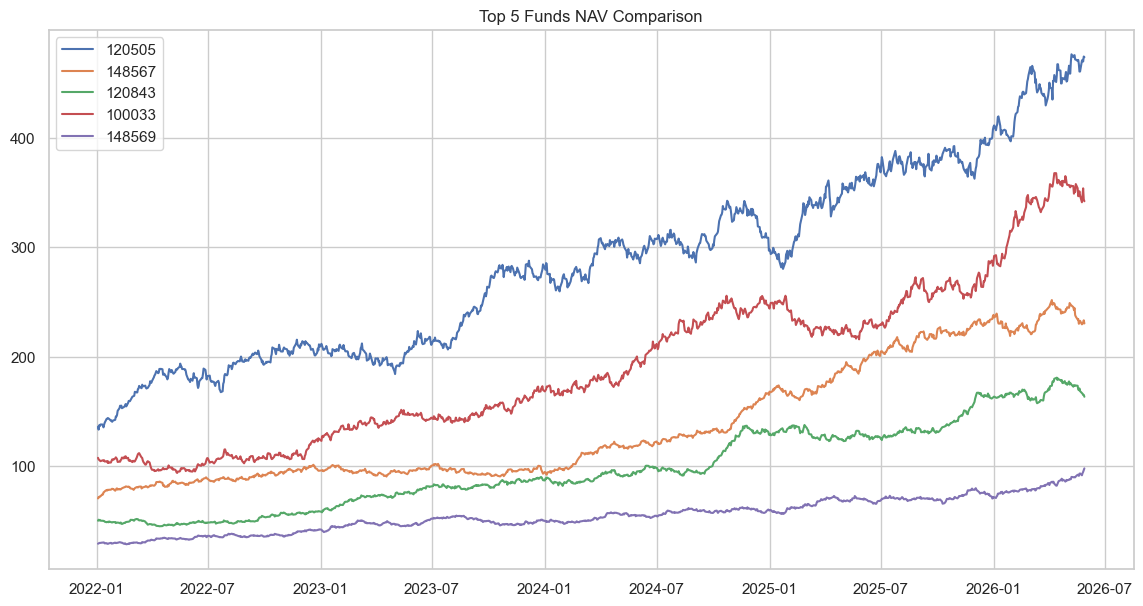

In [33]:
plt.figure(figsize=(14,7))

for code in top5:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=str(code)
    )

plt.title(
    "Top 5 Funds NAV Comparison"
)

plt.legend()

plt.savefig(
    "../reports/benchmark_comparison.png",
    bbox_inches="tight"
)

plt.show()

In [34]:
scorecard.head()

,amfi_code,cagr,sharpe_ratio,alpha,beta,max_drawdown,expense_ratio_pct,return_rank,sharpe_rank,alpha_rank,expense_rank,dd_rank,fund_score
25,120505,0.328016,1.180101,0.292636,0.000549,-0.181885,1.36,1.0,5.0,3.0,15.0,25.0,6.900
34,148567,0.309499,1.448291,0.269838,0.023684,-0.112657,1.46,5.0,1.0,7.0,23.0,8.0,7.400
30,120843,0.308833,1.306744,0.273305,-0.022830,-0.129740,1.45,6.0,2.0,5.0,22.0,13.0,7.900
2,100033,0.300997,1.093699,0.271954,0.005104,-0.162172,1.38,7.0,7.0,6.0,17.0,20.0,9.600
36,148569,0.319245,1.234930,0.282704,0.018134,-0.163967,1.60,4.0,3.0,4.0,36.5,21.0,10.325


# Key Findings

1. The highest CAGR fund delivered more than 32% annualized returns.
2. The best Sharpe Ratio exceeded 1.4, indicating strong risk-adjusted performance.
3. Several funds generated positive alpha against the benchmark.
4. Maximum drawdowns remained below 20% for top-performing schemes.
5. Expense ratios showed a measurable impact on overall fund rankings.
6. Risk-adjusted metrics produced different rankings than pure return metrics.
7. The composite scorecard identified the strongest all-round funds.